# Homework 4 - Linear Classification  
Breck, Fangyi, Luis

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

## Problem 1: Generating Data    

Generate two 2D Gaussian clusters:
$$
\mathbf{x}_0 \sim \mathcal{N}\!\left((0,0), I\right)
$$
$$
\mathbf{x}_1 \sim \mathcal{N}\!\left((\mu,0), I\right)
$$

where $I$ is the identity matrix.

1. Plot the data for $\mu = 3$.
2. Label each point by its class.

---

In [ ]:
def make_data(mu, n0=200, n1=200, seed=0):
    rng = np.random.default_rng(seed)

    x0 = rng.multivariate_normal(mean=[0, 0], cov=[[1, 0], [0, 1]], size=n0)
    x1 = rng.multivariate_normal(mean=[mu, 0], cov=[[1, 0], [0, 1]], size=n1)

    X = np.vstack([x0, x1])
    y = np.array([0] * n0 + [1] * n1)

    return X, y, x0, x1

def plot_data(x0, x1, mu):
    plt.figure()
    plt.scatter(x0[:, 0], x0[:, 1], alpha=0.7, label="class 0")
    plt.scatter(x1[:, 0], x1[:, 1], alpha=0.7, label="class 1")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(rf"Two Gaussian clusters ($\mu$ = {mu})")
    plt.legend()
    plt.tight_layout()
    plt.show()

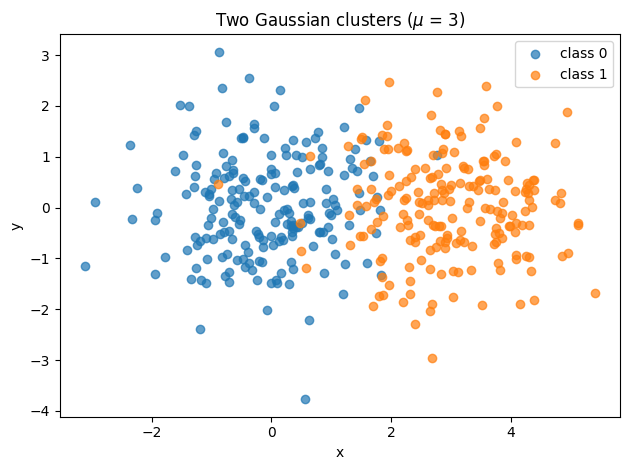

In [34]:
X, y, x0, x1 = make_data(mu=3, seed=0)

plot_data(x0, x1, mu=3)

## Problem 2: Linear Classifier  

Using `sklearn.linear_model.LogisticRegression`:

1. Fit a classifier to the data.
2. Plot the decision boundary.
3. Shade the predicted probability regions.

---

In [24]:
def fit_classifier(X, y):
    clf = LogisticRegression()
    clf.fit(X, y)
    return clf


def plot_classifier(clf, X, y, mu):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = clf.predict_proba(grid)[:, 1].reshape(xx.shape)

    plt.figure()

    plt.contourf(xx, yy, probs, levels=20, alpha=0.4)
    plt.contour(xx, yy, probs, levels=[0.5], colors="black", linewidths=2)

    plt.scatter(X[y == 0, 0], X[y == 0, 1], alpha=0.8, label="class 0")
    plt.scatter(X[y == 1, 0], X[y == 1, 1], alpha=0.8, label="class 1")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(rf"Logistic regression decision boundary ($\mu$ = {mu})")
    plt.legend()
    plt.tight_layout()
    plt.show()

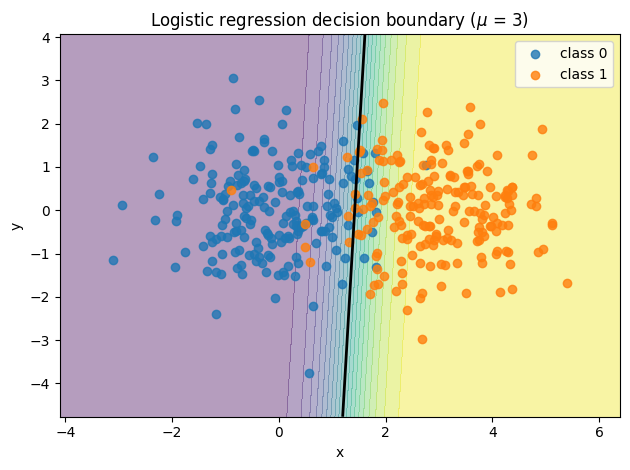

In [35]:
clf = fit_classifier(X, y)
plot_classifier(clf, X, y, mu=3)

## Problem 3: Performance vs Separation  

Repeat the experiment for:
$$
\mu = 3,\; 2,\; 1,\; 0.5
$$

For each case compute:
- Accuracy
- False positive rate
- False negative rate

Plot accuracy versus $\mu$.

---


For mu = 3:
Accuracy = 0.948
False positive rate = 0.060
False negative rate = 0.045

For mu = 2:
Accuracy = 0.835
False positive rate = 0.150
False negative rate = 0.180

For mu = 1:
Accuracy = 0.708
False positive rate = 0.280
False negative rate = 0.305

For mu = 0.5:
Accuracy = 0.605
False positive rate = 0.405
False negative rate = 0.385


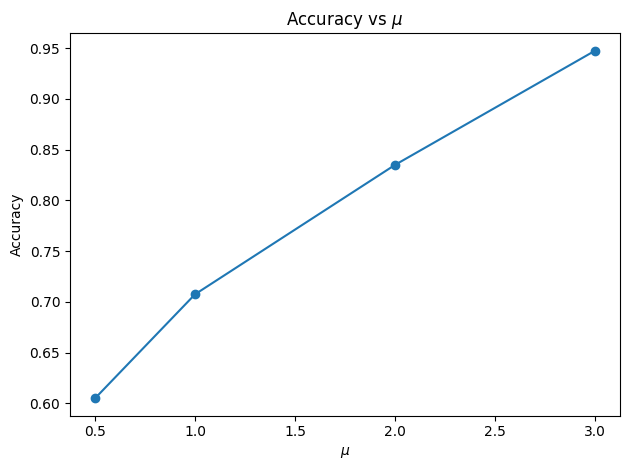

In [43]:
def compute_metrics(clf, X, y):
    y_pred = clf.predict(X)

    acc = accuracy_score(y, y_pred)

    cm = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()

    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)

    return acc, fpr, fnr

mus = [3, 2, 1, 0.5]
accs = []
fprs = []
fnrs = []

for mu in mus:
    X, y, x0, x1 = make_data(mu=mu, seed=0)
    clf = fit_classifier(X, y)
    acc, fpr, fnr = compute_metrics(clf, X, y)

    accs.append(acc)
    fprs.append(fpr)
    fnrs.append(fnr)

    print(f"\nFor mu = {mu}:")
    print(f"Accuracy = {acc:.3f}")
    print(f"False positive rate = {fpr:.3f}")
    print(f"False negative rate = {fnr:.3f}")

plt.figure()
plt.plot(mus, accs, marker="o", label="Accuracy")
plt.xlabel(r"$\mu$")
plt.ylabel("Accuracy")
plt.title(r"Accuracy vs $\mu$")
plt.tight_layout()
plt.show()


## Problem 4: Interpretation

1. Why does performance degrade as $\mu\to 0$?

As $\mu\to0$, the two Gaussian clusters overlap more and more and become inseparable. As a result, the classifier is harder to distinguish the two clusters and the performance degrades.

2. Does adding more data help when $\mu=0$?

No. When $\mu=0$, the two clusters have the same distribution, and are completely indistinguishable. Adding more data does not creat separability for the classifier. The most accurate classifier would just be the random guess.

3. What assumption does a linear classifier make about the data?

A linear classifier assumes that the data classes can be separated by a plane which has one less dimension than the number of classes. It makes sense only when there are few data points that are mistakenly classified. 